In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plt

In [7]:
from google.colab import files

uploaded = files.upload()

In [8]:
import zipfile

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [9]:
import os

os.listdir("/content/music_instruments")

['saxophone',
 'flute',
 'violin',
 'sitar',
 'dataset_stats.csv',
 'tabla',
 'harmonica',
 'guitar',
 'drum',
 'accordion',
 'banjo']

In [10]:
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 15

DATASET_PATH = "music_instruments"

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 1448 images belonging to 10 classes.
Found 358 images belonging to 10 classes.


In [12]:
model = models.Sequential([

    # 1 блок
    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2,2),

    # 2 блок
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # 3 блок
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # 4 блок
    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Преобразование в вектор
    layers.Flatten(),

    # Полносвязные слои
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    # Выходной слой
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,750,538 (10.49 MB)

 Trainable params: 2,750,538 (10.49 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.1215 - loss: 2.2933 - val_accuracy: 0.1788 - val_loss: 2.2553
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.2093 - loss: 2.1814 - val_accuracy: 0.2570 - val_loss: 2.0452
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.2604 - loss: 2.0748 - val_accuracy: 0.3017 - val_loss: 1.9295
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.2935 - loss: 1.9642 - val_accuracy: 0.3631 - val_loss: 1.9047
Epoch 5/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.3363 - loss: 1.8931 - val_accuracy: 0.4022 - val_loss: 1.7825
Epoch 6/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.3508 - loss: 1.8322 - val_accuracy: 0.3771 - val_loss: 1.8048
Epoch 7/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.3660 - loss: 1.7961 - val_accuracy: 0.4218 - val_loss: 1.6917
Epoch 8/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.4171 - loss: 1.6865 - val_accuracy: 0.4832 - val_loss:

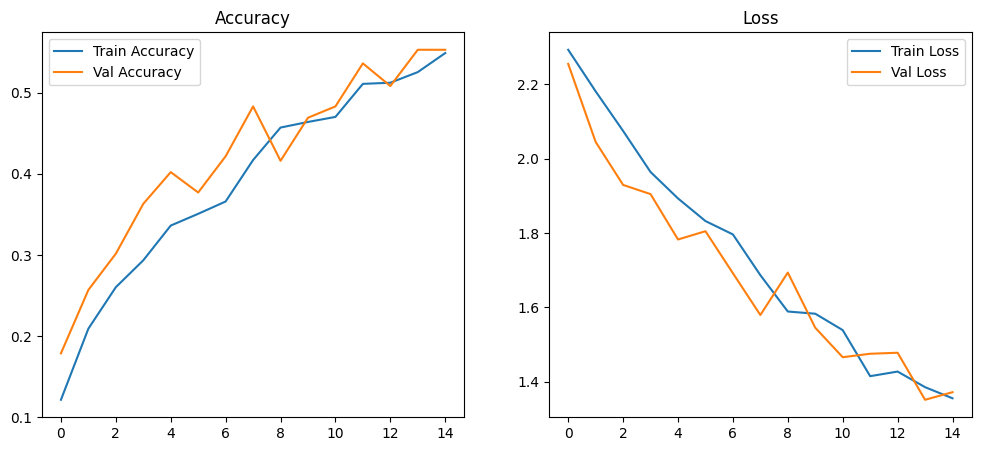

In [16]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [17]:
model.save("music_instruments_cnn.h5")

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 491ms/step


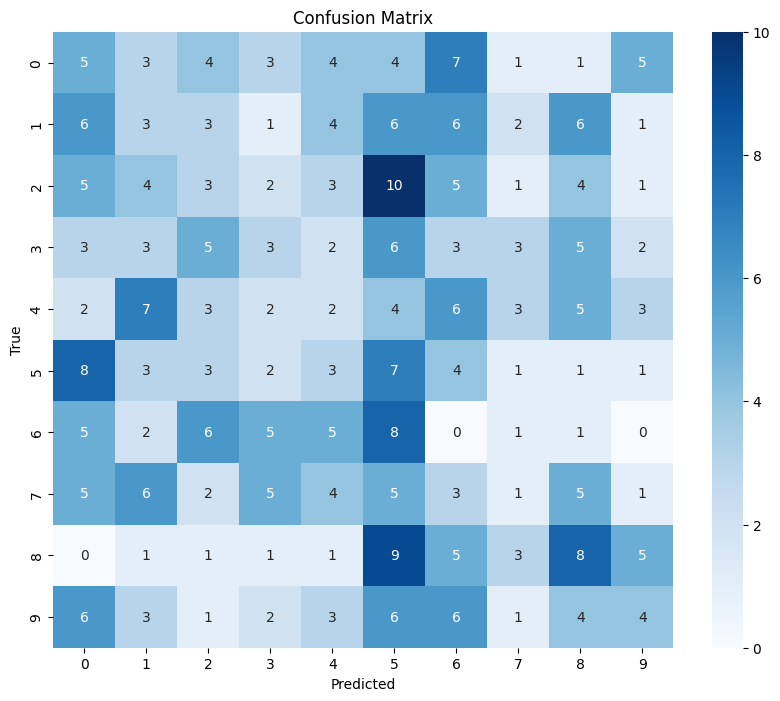

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

y_true = val_generator.classes

y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

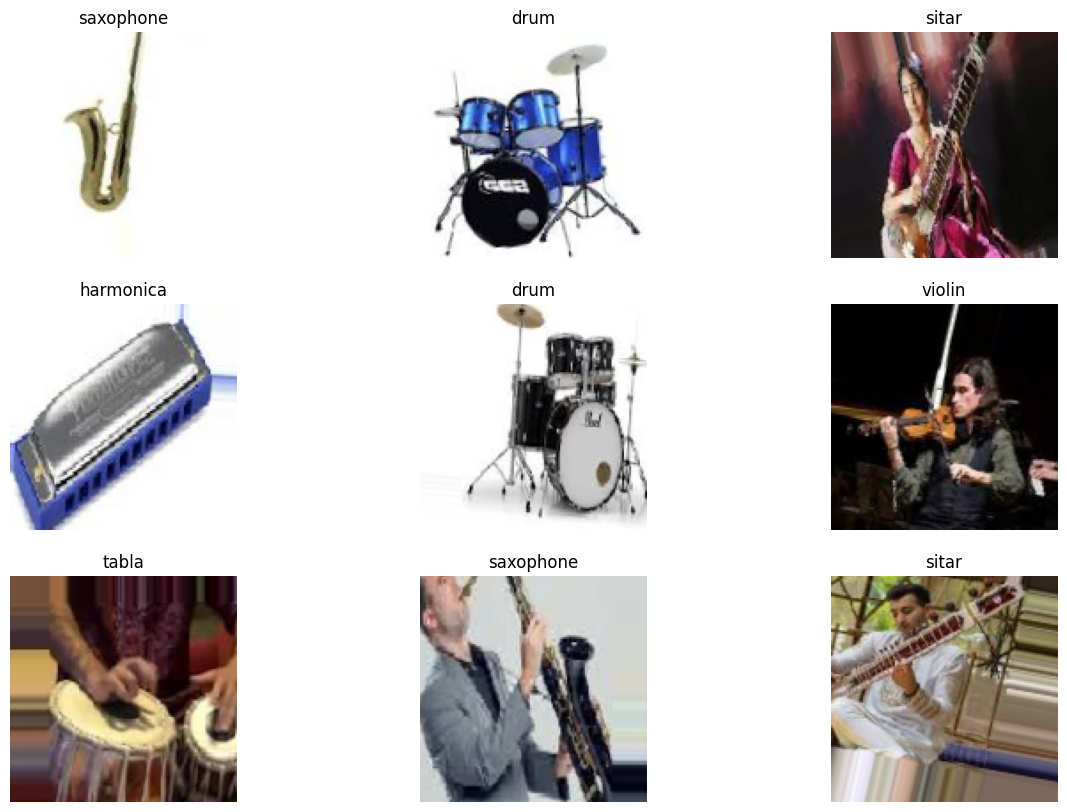

In [19]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.figure(figsize=(15,10))

for i in range(9):
    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    class_index = labels[i].argmax()
    class_name = list(train_generator.class_indices.keys())[class_index]

    plt.title(class_name)
    plt.axis("off")

plt.show()

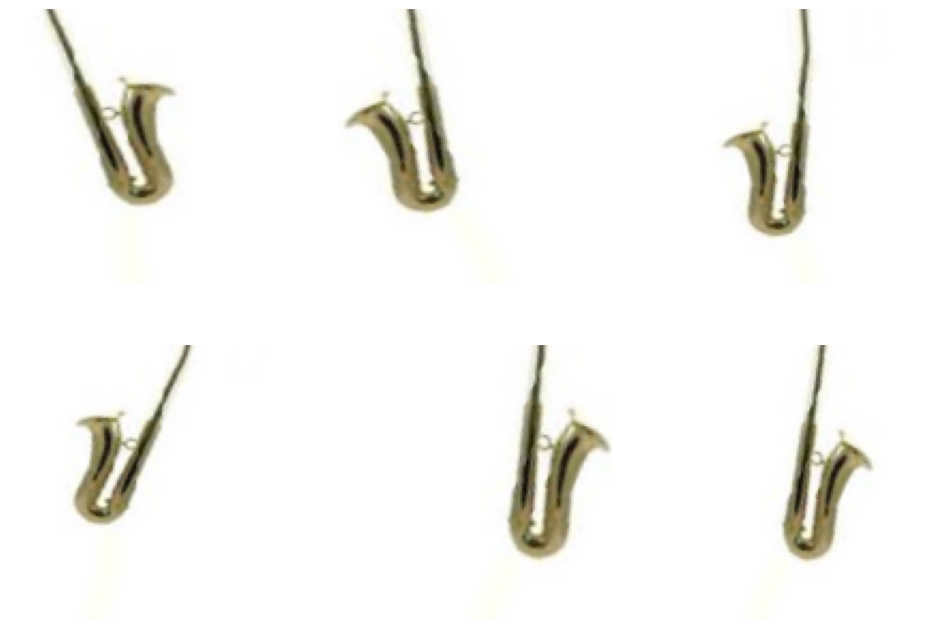

In [20]:
sample_image = images[0]

plt.figure(figsize=(12,8))

for i in range(6):
    augmented = train_datagen.random_transform(sample_image)

    plt.subplot(2,3,i+1)
    plt.imshow(augmented)
    plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step


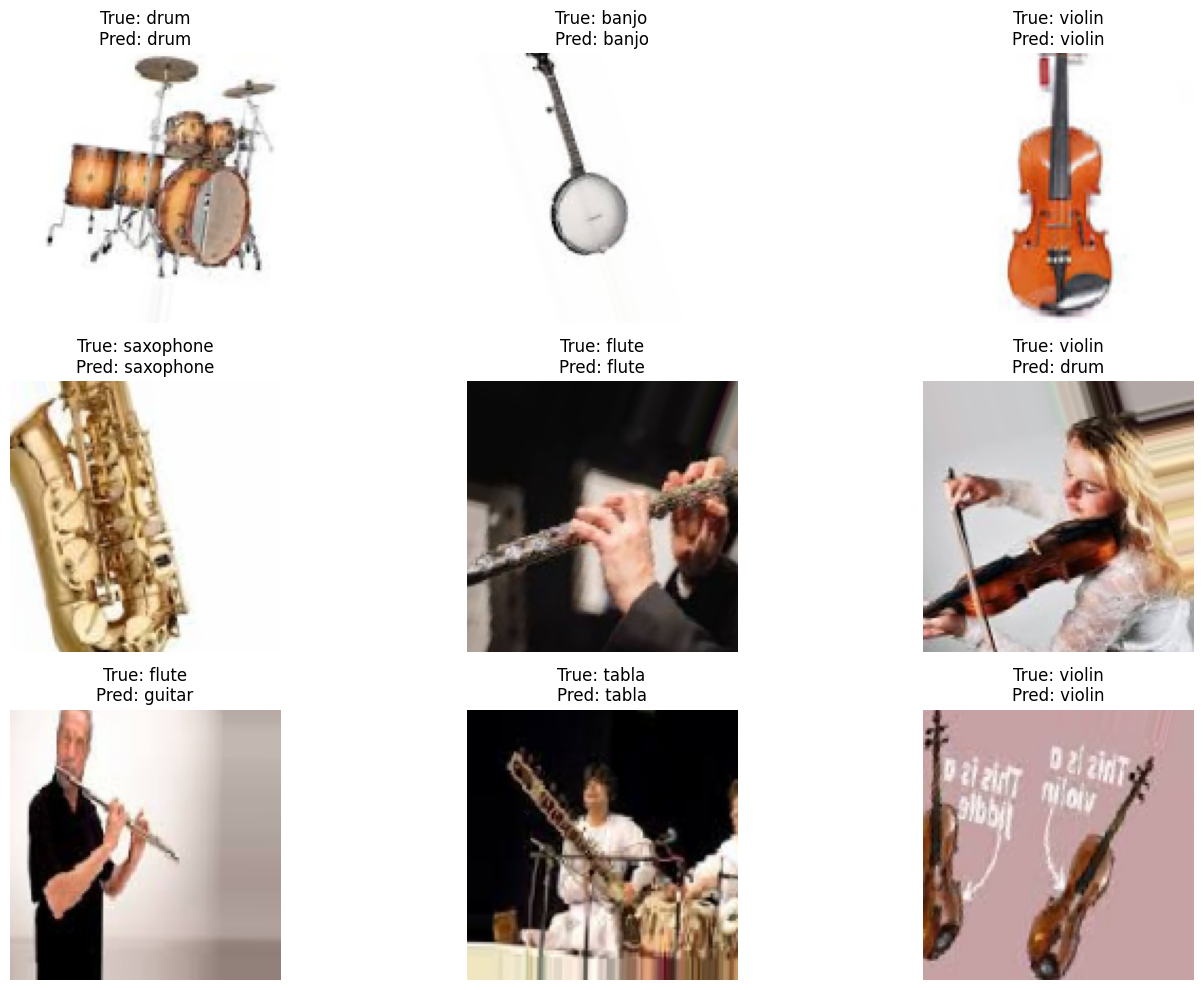

In [21]:
import numpy as np

images, labels = next(val_generator)

predictions = model.predict(images)

plt.figure(figsize=(15,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    true_class = list(val_generator.class_indices.keys())[np.argmax(labels[i])]
    predicted_class = list(val_generator.class_indices.keys())[np.argmax(predictions[i])]

    plt.title(f"True: {true_class}\nPred: {predicted_class}")

    plt.axis("off")

plt.tight_layout()
plt.show()

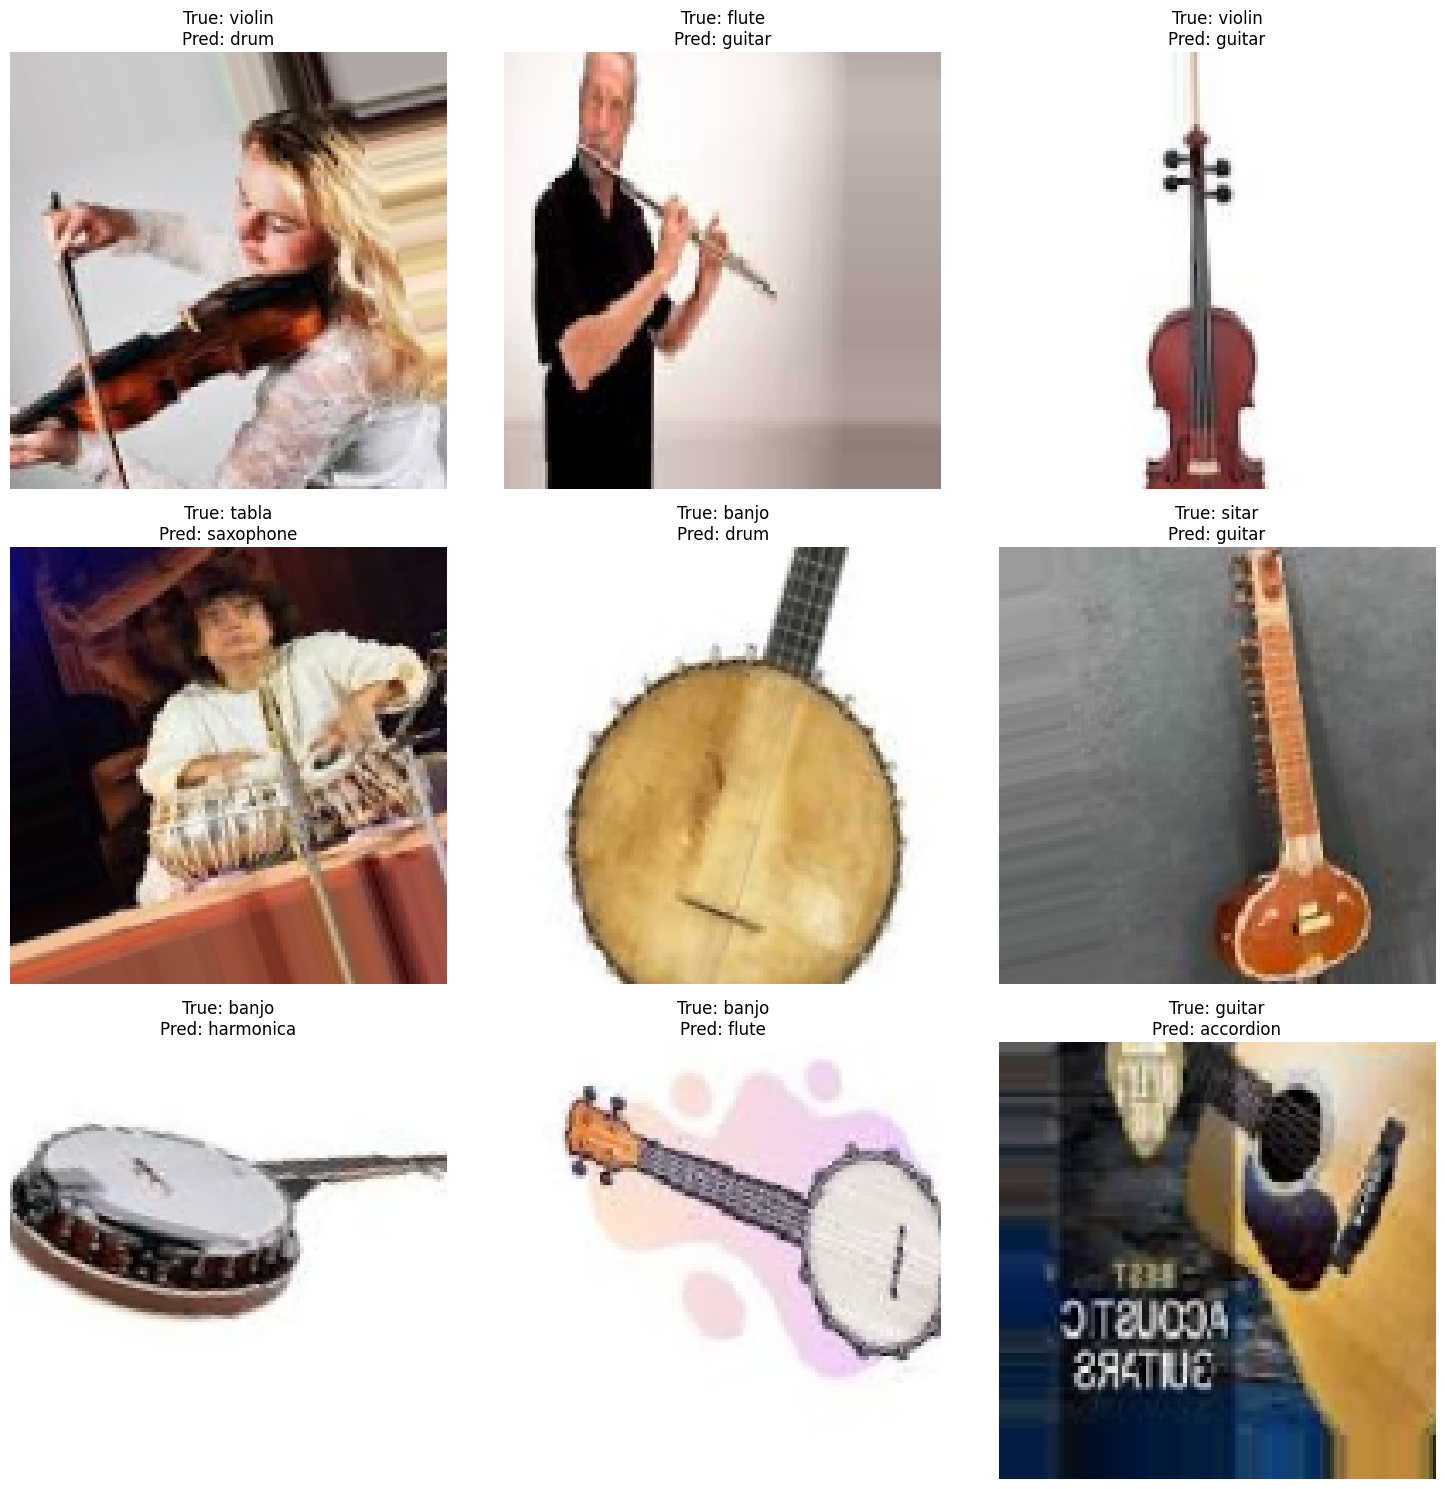

In [22]:
plt.figure(figsize=(15,15))

counter = 1

for i in range(len(images)):

    true_class = np.argmax(labels[i])
    pred_class = np.argmax(predictions[i])

    if true_class != pred_class:

        plt.subplot(3,3,counter)

        plt.imshow(images[i])

        true_name = list(val_generator.class_indices.keys())[true_class]
        pred_name = list(val_generator.class_indices.keys())[pred_class]

        plt.title(f"True: {true_name}\nPred: {pred_name}")

        plt.axis("off")

        counter += 1

    if counter > 9:
        break

plt.tight_layout()
plt.show()

In [23]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

In [24]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [25]:
model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

In [26]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 38s 709ms/step - accuracy: 0.6243 - loss: 1.2155 - val_accuracy: 0.8324 - val_loss: 0.5128
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 44s 768ms/step - accuracy: 0.8280 - loss: 0.5583 - val_accuracy: 0.8547 - val_loss: 0.4567
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 30s 661ms/step - accuracy: 0.8529 - loss: 0.4692 - val_accuracy: 0.8520 - val_loss: 0.3938
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 30s 656ms/step - accuracy: 0.8640 - loss: 0.4237 - val_accuracy: 0.8994 - val_loss: 0.3710
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 32s 694ms/step - accuracy: 0.8819 - loss: 0.3702 - val_accuracy: 0.8687 - val_loss: 0.3908
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 30s 657ms/step - accuracy: 0.8930 - loss: 0.3251 - val_accuracy: 0.8966 - val_loss: 0.3592
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 30s 654ms/step - accuracy: 0.9019 - loss: 0.2995 - val_accuracy: 0.8436 - val_loss: 0.4735
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 31s 671ms/step - accuracy: 0.9157 - loss: 0.2610 - val_accu

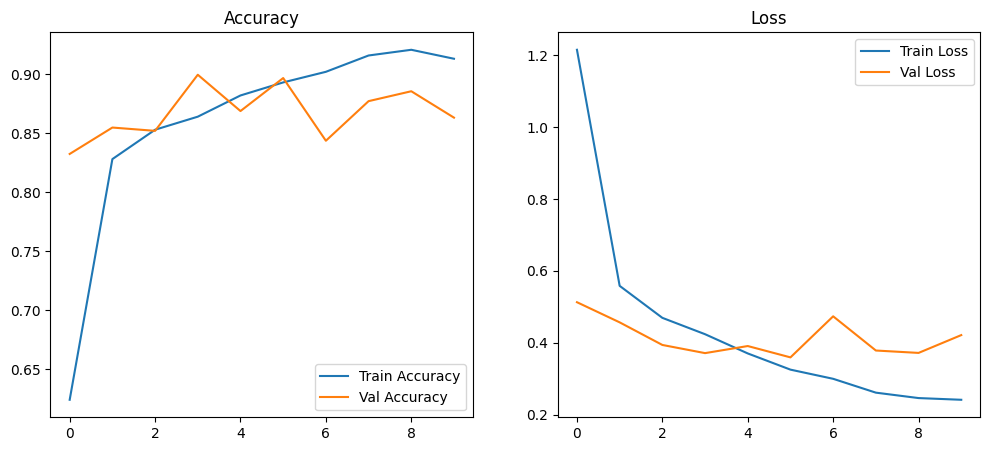

In [28]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 570ms/step


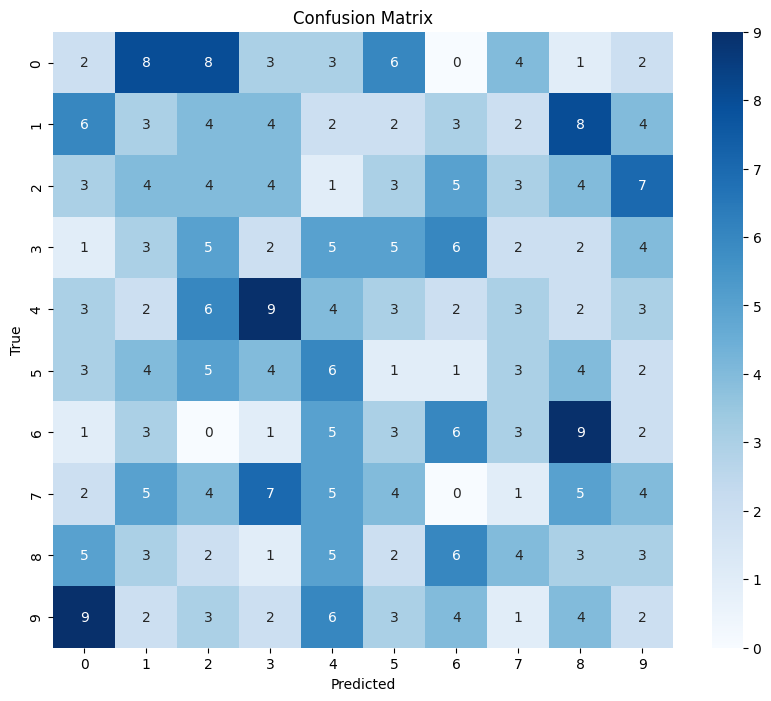

In [29]:
y_true = val_generator.classes

y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()